In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import scienceplots

from sklearn.metrics import auc

from src import *

In [28]:
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams.update({'font.size': 9})
colors = [plt.colormaps['tab20'](i) for i in range(20)]

markersize = 3
styles = dict(
    random=dict(linestyle='--', color='gray'),
        amsp=dict(color=colors[0], markersize=markersize, marker="v"),
        ane=dict(color=colors[1], markersize=markersize, marker="p"),
        mmmc=dict(color=colors[2], markersize=markersize, marker="D"),
        qtc=dict(color=colors[3], markersize=markersize, marker="^"),
        pll=dict(color=colors[4], markersize=markersize, marker="o"),
        sdc=dict(color=colors[5], markersize=markersize, marker="s"),
        aef=dict(color=colors[6], markersize=markersize, marker="*"),
        aef_sdc=dict(color=colors[7], markersize=markersize, marker="h"),
        oracle=dict(color=colors[8], markersize=markersize, marker="--"),
        idc_true=dict(color=colors[9], marker="*", zorder=-2),
        idc_hat=dict(color=colors[10], markersize=markersize+2, marker=".", zorder=-1),
)

# Ideal Model

## Small RC Curve

In [29]:
with open(f"ideal_model_n_10_results.pkl", "rb") as f:
    results = pickle.load(f)

with open(f"ideal_model_n_10_rc_curve_small.pkl", "rb") as f:
    curves = pickle.load(f)

for k in curves.keys():
    if k != "bounds":
        print(k)
        print(auc(*curves[k]))

IDC_FP
0.10535938820682154
IDC_MAR
0.10546919248799505
aMSP
0.12287692577838152
SDC
0.10631229727306651


In [30]:
100 * (0.12267103118872508 - 0.1050231051612263) / 0.1050231051612263

16.803850924429007

In [31]:
print("Total samples = ", len(results["R_x"]))

Total samples =  5000


0.045292283752955190935


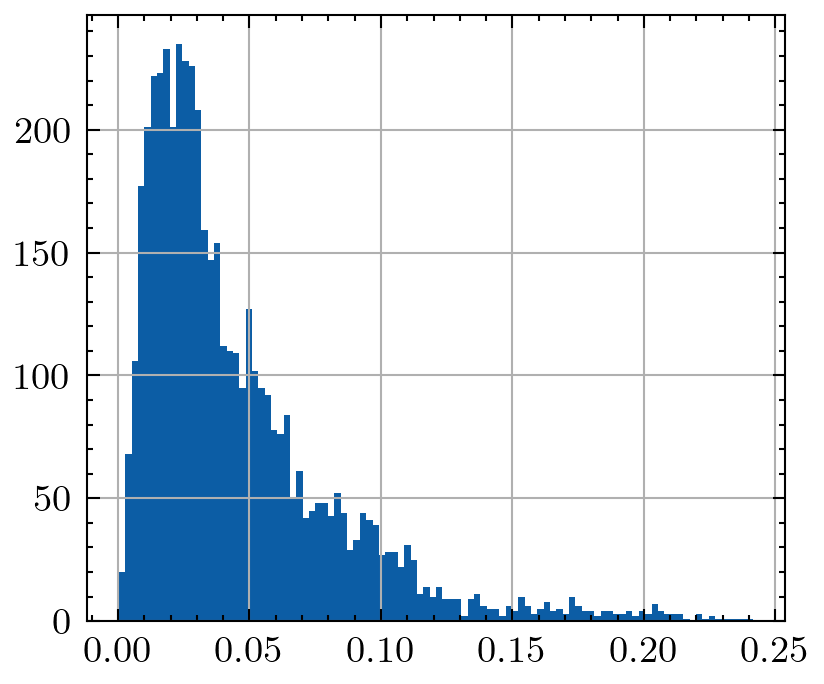

In [32]:
def bounds_is_nan(bounds):
    try:
        return any(np.isnan(bounds))
    except TypeError:
        return np.isnan(bounds)

all_boounds = np.vstack([bounds for bounds in results["bounds"] if not bounds_is_nan(bounds)])

eps_bounds = [max(1-1/bounds[0], 1/bounds[1] - 1) for bounds in all_boounds]

print(np.mean(eps_bounds))
plt.hist(eps_bounds, bins=100)
plt.show()

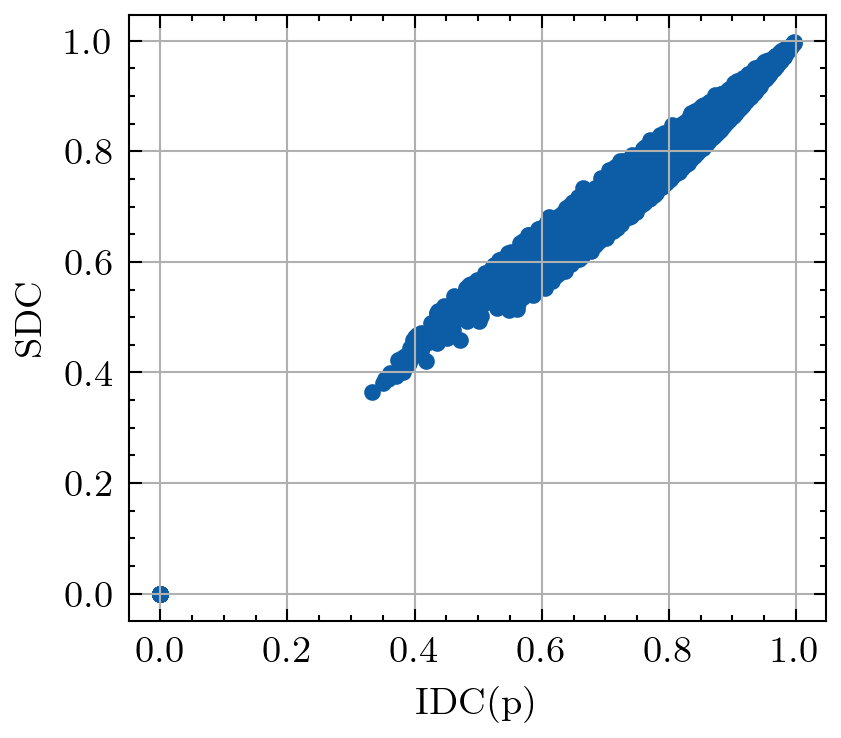

In [33]:
R_x = results["R_x"]
sdc = results["SDC"]
idc_x = results["IDC_FP"]
idc_p = results["IDC_MAR"]

plt.scatter(idc_p, sdc, marker='.')
plt.xlabel("IDC(p)")
plt.ylabel("SDC")
plt.show()

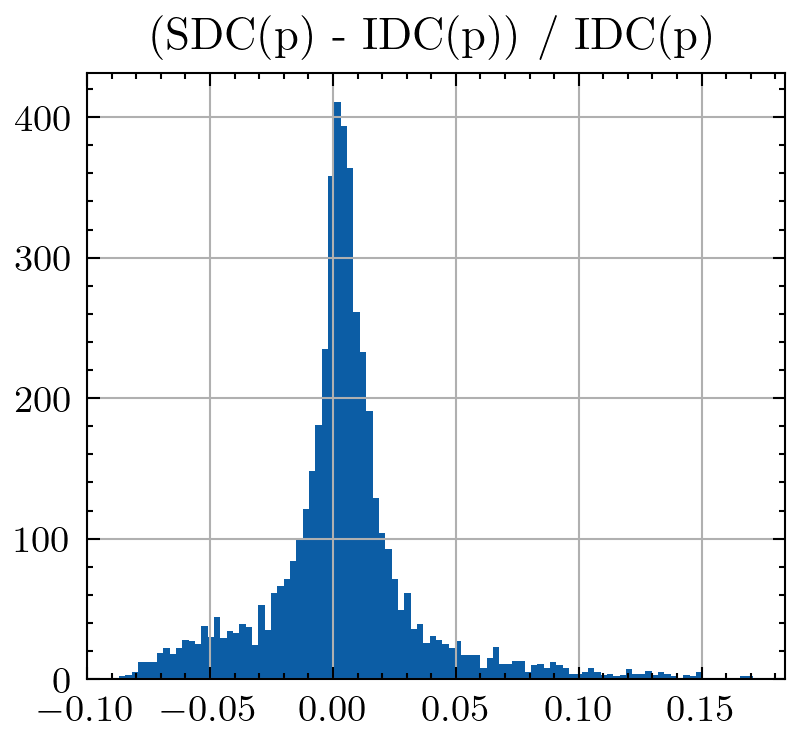

In [34]:
plt.hist((sdc - idc_p)[idc_p != 0] / idc_p[idc_p != 0], bins=100)
plt.title("(SDC(p) - IDC(p)) / IDC(p)")
plt.show()

10  runs of  100  samples each


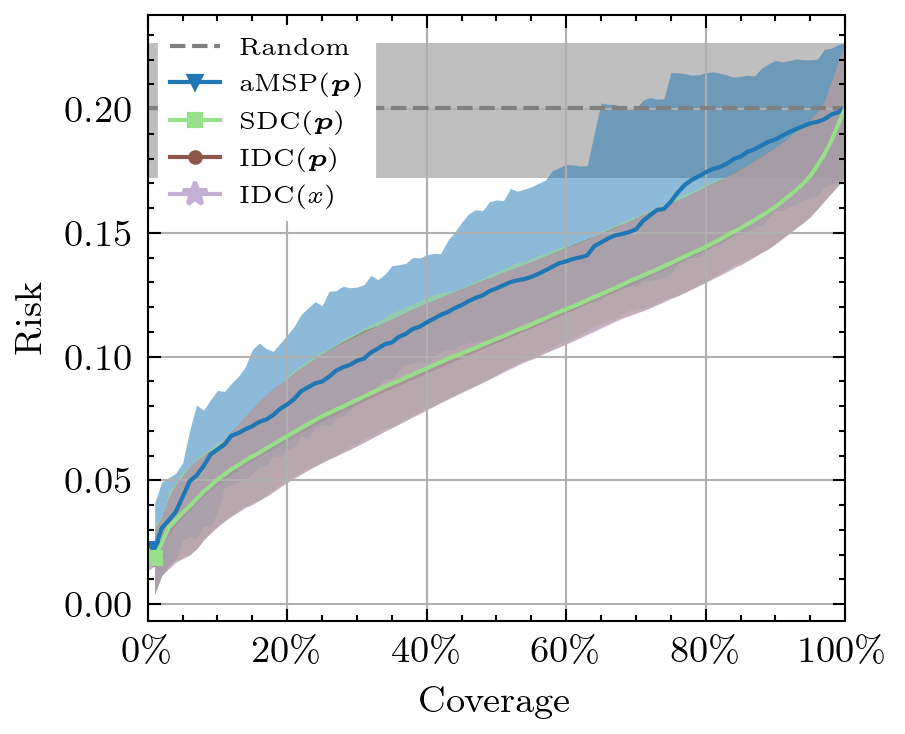

In [24]:
r = 10
N = len(results["R_x"])
N_sample = int(N / r)

print(r, " runs of ", N_sample, " samples each")

def get_rc_min_mean_max(results, key):
    risks = np.zeros((r, N_sample))
    coverages = np.zeros((r, N_sample))
    for i in range(r):
        samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
        R_x = results["R_x"][samples_slicer]
        conf = results[key][samples_slicer]

        risks[i], coverages[i] = rc_curve_(R_x, conf)

    assert np.allclose(coverages, coverages[0]), "coverages is not identical across the first axis"

    return dict(
        coverages = coverages[0],
        min = np.min(risks, axis=0),
        mean = np.mean(risks, axis=0),
        max = np.max(risks, axis=0),
    )

idc_fp  = get_rc_min_mean_max(results, "IDC_FP")
idc_mar = get_rc_min_mean_max(results, "IDC_MAR")
amsp = get_rc_min_mean_max(results, "aMSP")
sdc = get_rc_min_mean_max(results, "SDC")

fig, ax = plt.subplots()

markevery = 500

ax.fill_between([0,1], 2*[idc_fp["min"][-1],], 2*[idc_fp["max"][-1],], alpha=0.5, linewidth=0, color=styles["random"]["color"])
ax.hlines(idc_fp["mean"][-1], 0, 1, **styles["random"], label="Random")

def add_rc_fill(ax, rc, style_tag, label=None):
    ax.fill_between(rc["coverages"], rc["min"], rc["max"], alpha=0.5, linewidth=0, color=styles[style_tag]["color"])
    ax.plot(rc["coverages"], rc["mean"], **styles[style_tag], markevery=markevery, label=label)

add_rc_fill(ax, amsp, "amsp", label=r"aMSP($\boldsymbol{p}$)")
add_rc_fill(ax, sdc, "sdc", label=r"SDC($\boldsymbol{p}$)")
add_rc_fill(ax, idc_mar, "idc_hat", label=r"IDC($\boldsymbol{p}$)")
add_rc_fill(ax, idc_fp, "idc_true", label=r"IDC($x$)")

ax.legend()
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk")

fig.show()
fig.savefig("ideal_model_rc_short_nruns.pdf")

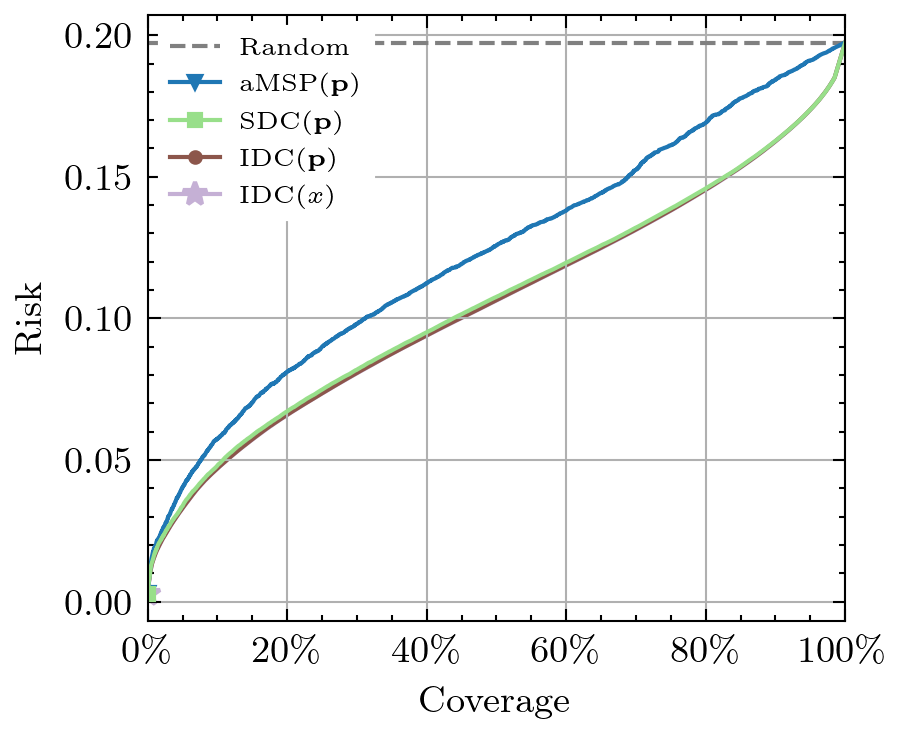

In [35]:
fig, ax = plt.subplots()

markevery = 5000

idc_fp_coverages, idc_fp_risks = curves["IDC_FP"]
ax.hlines(idc_fp_risks[-1], 0, 1, **styles["random"], label="Random")

idc_mar_coverages, idc_mar_risks = curves["IDC_MAR"]

coverages, risks = curves["aMSP"]
ax.plot(coverages, risks, **styles["amsp"], markevery=markevery, label=r"aMSP(\textbf{p})")

coverages, sdc_risks = curves["SDC"]
ax.plot(coverages, sdc_risks, **styles["sdc"], markevery=markevery, label=r"SDC(\textbf{p})")

ax.plot(idc_mar_coverages, idc_mar_risks, **styles["idc_hat"], markevery=markevery, label=r"IDC(\textbf{p})")

ax.plot(idc_fp_coverages, idc_fp_risks, **styles["idc_true"], markevery=markevery, label=r"IDC($x$)")

ax.legend()
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk")

fig.show()
fig.savefig("ideal_model_rc_short.pdf")

## Varying Prevalence

10  runs of  5000  samples each


/tmp/ipykernel_3749351/4176834957.py:62: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])


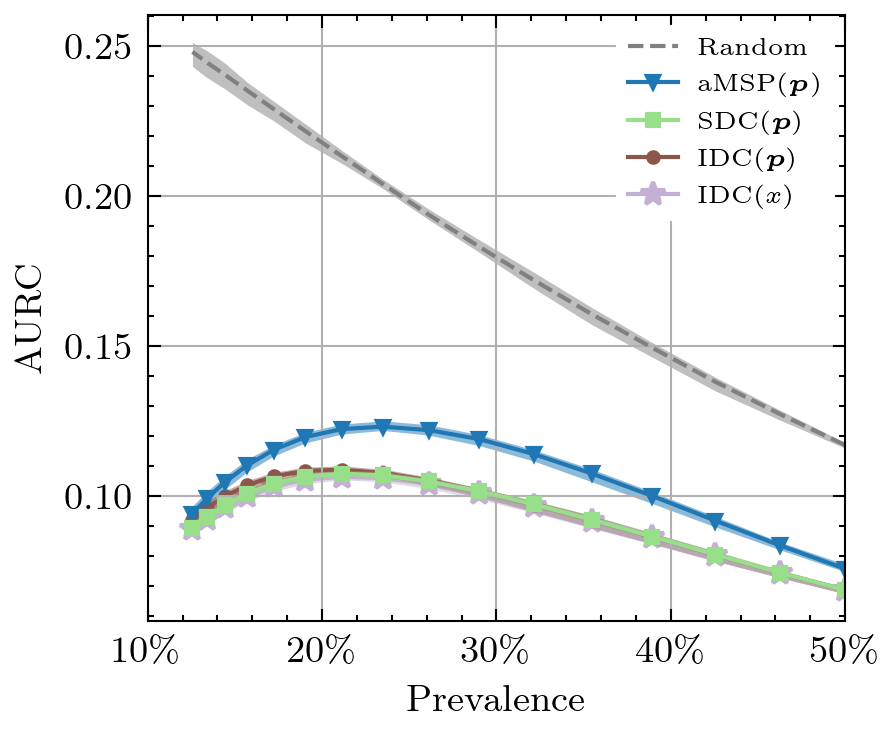

In [34]:
with open(f"ideal_model_n_10_varying_prev.pkl", "rb") as f:
    data = pickle.load(f)

with open(f"ideal_model_n_10_varying_prev_results.pkl", "rb") as f:
    raw_results = pickle.load(f)

prevalences = data["prevalences"]

r = 10
N = len(raw_results[0]["R_x"])
N_sample = int(N / r)

print(r, " runs of ", N_sample, " samples each")

def get_aucs(raw_results, key):
    aucss = list()
    for raw_result in raw_results:
        aucs = list()
        for i in range(r):
            samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
            R_x = raw_result["R_x"][samples_slicer]
            conf = raw_result[key][samples_slicer]

            risks, coverages = rc_curve_(R_x, conf)
            aucs.append(auc(coverages, risks))
        aucss.append(np.array(aucs))

    return np.array(aucss)

sdc_aucs = get_aucs(raw_results, "SDC")
msp_aucs = get_aucs(raw_results, "aMSP")
idc_fp_aucs = get_aucs(raw_results, "IDC_FP")
idc_mar_aucs = get_aucs(raw_results, "IDC_MAR")

random_aucs = np.zeros_like(idc_fp_aucs)
for j, raw_result in enumerate(raw_results):
    for i in range(r):
        samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
        R_x = raw_result["R_x"][samples_slicer]

        risks, _ = rc_curve_(R_x, -R_x)
        random_aucs[j, i] = risks[-1]

def add_rc_fill(ax, aucs, style_tag, label=None):
    aucs_min = np.min(aucs, axis=1)
    aucs_mean = np.mean(aucs, axis=1)
    aucs_max = np.max(aucs, axis=1)
    ax.fill_between(prevalences, aucs_min, aucs_max, alpha=0.5, linewidth=0, color=styles[style_tag]["color"])
    ax.plot(prevalences, aucs_mean, **styles[style_tag], label=label)

fig, ax = plt.subplots()

add_rc_fill(ax, random_aucs, "random", label=r"Random")
add_rc_fill(ax, msp_aucs, "amsp", label=r"aMSP($\boldsymbol{p}$)")
add_rc_fill(ax, sdc_aucs, "sdc", label=r"SDC($\boldsymbol{p}$)")
add_rc_fill(ax, idc_mar_aucs, "idc_hat", label=r"IDC($\boldsymbol{p}$)")
add_rc_fill(ax, idc_fp_aucs, "idc_true", label=r"IDC($x$)")

ax.set_xlim(0.1,0.5)
ax.set_xlabel("Prevalence")
ax.set_ylabel("AURC")
ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])
ax.legend()

fig.show()
fig.savefig("ideal_model_varying_prev_nruns.pdf")

/tmp/ipykernel_1160/1138292401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])


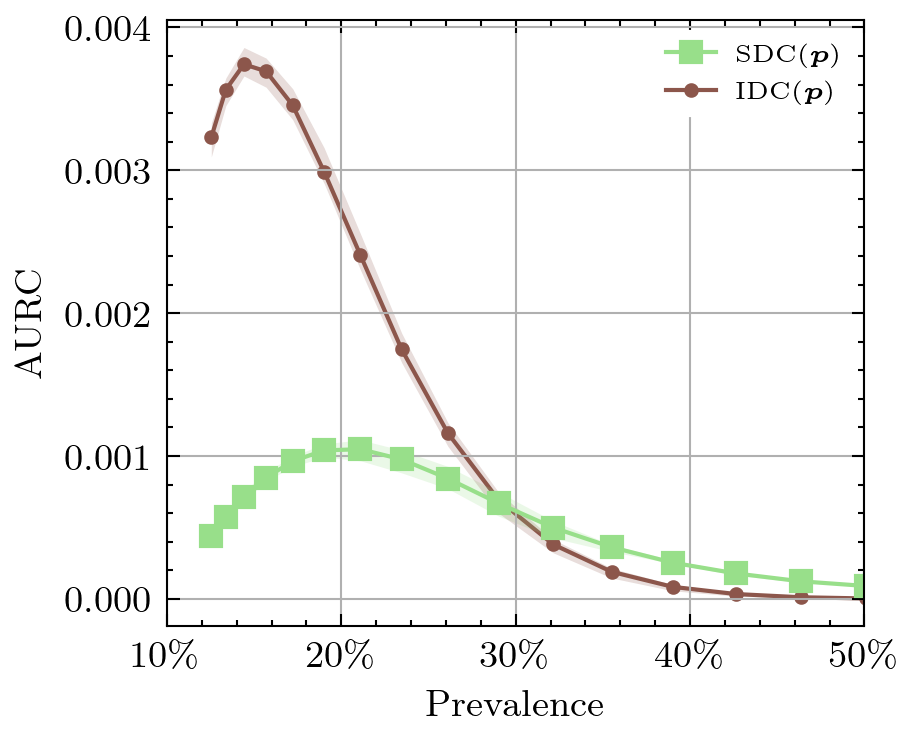

In [138]:
fig, ax = plt.subplots()

ref = np.repeat(np.mean(idc_fp_aucs, axis=1)[:,np.newaxis], 5, axis=1)
add_rc_fill(ax, sdc_aucs - idc_fp_aucs, "sdc", label=r"SDC($\boldsymbol{p}$)")
add_rc_fill(ax, idc_mar_aucs - idc_fp_aucs, "idc_hat", label=r"IDC($\boldsymbol{p}$)")

ax.set_xlim(0.1,0.5)
ax.set_xlabel("Prevalence")
ax.set_ylabel("AURC")
ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])
ax.legend()

fig.show()

/tmp/ipykernel_2266514/3113809077.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])


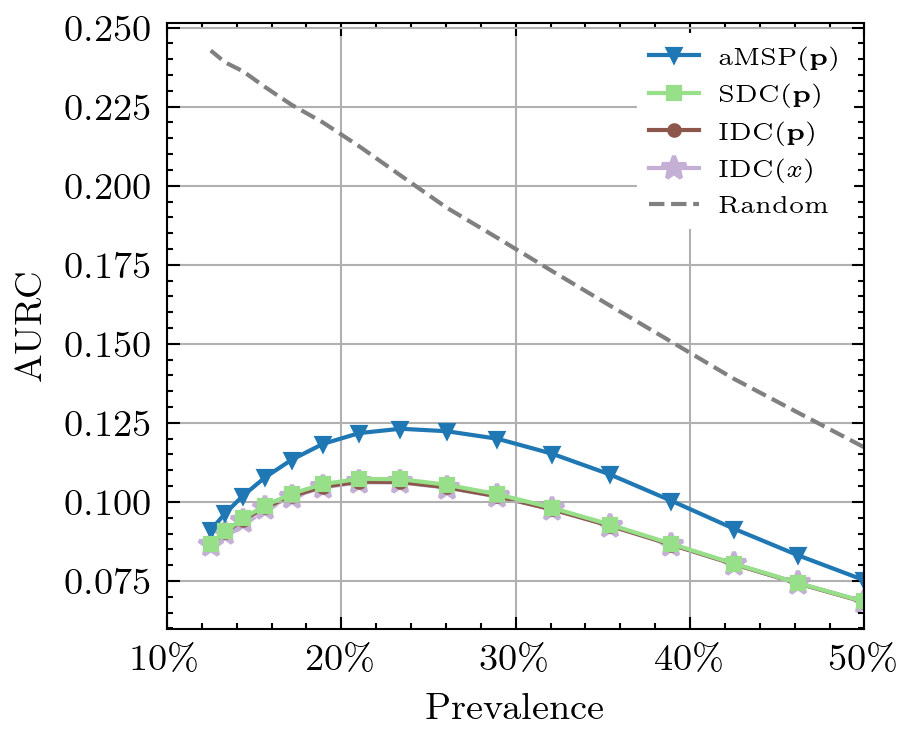

In [36]:
with open(f"ideal_model_n_10_varying_prev.pkl", "rb") as f:
    data = pickle.load(f)

prevalences = data["prevalences"]
sdc_aucs = data["sdc_aucs"]
msp_aucs = data["msp_aucs"]
idc_fp_aucs = data["idc_fp_aucs"]
idc_mar_aucs = data["idc_mar_aucs"]
random_aucs = data["random_aucs"]

fig, ax = plt.subplots()

ax.plot(prevalences, msp_aucs, **styles["amsp"], label=r"aMSP(\textbf{p})")
ax.plot(prevalences, sdc_aucs, **styles["sdc"], label=r"SDC(\textbf{p})")
ax.plot(prevalences, idc_mar_aucs, **styles["idc_hat"], label=r"IDC(\textbf{p})")
ax.plot(prevalences, idc_fp_aucs, **styles["idc_true"], label=r"IDC($x$)")
ax.plot(prevalences, random_aucs, **styles["random"], label="Random")

ax.set_xlim(0.1,0.5)
ax.set_xlabel("Prevalence")
ax.set_ylabel("AURC")
ax.set_xticklabels(['{:.0f}\%'.format(100*x) for x in ax.get_xticks()])
ax.legend()

fig.show()
fig.savefig("ideal_model_varying_prev.pdf")

# Perturbed Model

## Small RC Curve

10  runs of  5000  samples each


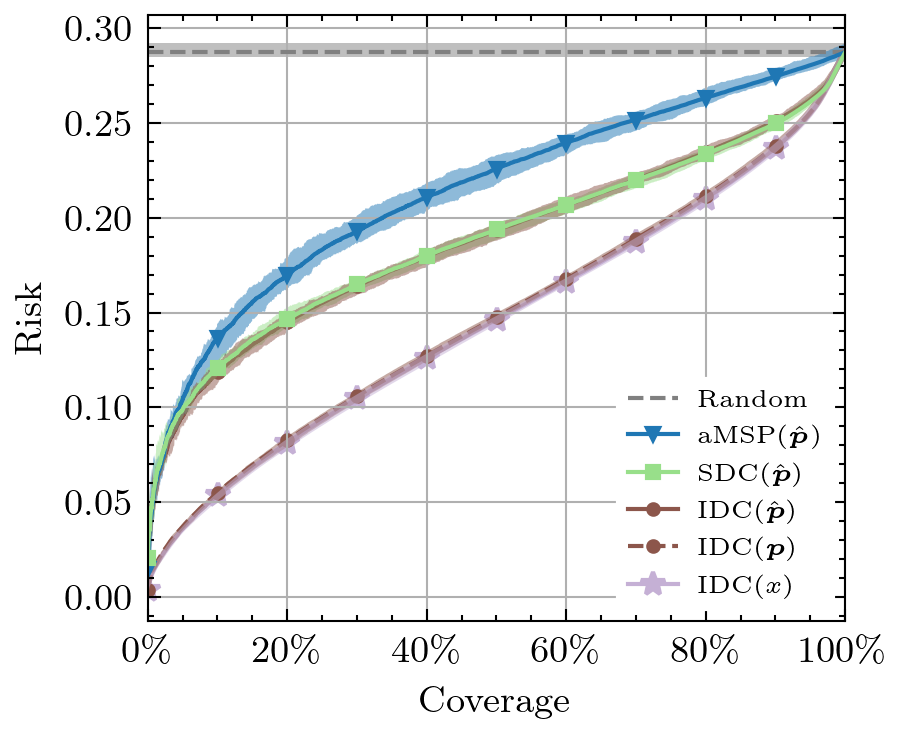

In [35]:
with open(f"perturbed_model_n_10_results.pkl", "rb") as f:
    results = pickle.load(f)

with open(f"perturbed_model_n_10_rc_curve_small.pkl", "rb") as f:
    curves = pickle.load(f)

r = 10
N = len(results["R_x"])
N_sample = int(N / r)

print(r, " runs of ", N_sample, " samples each")

def get_rc_min_mean_max(results, key):
    risks = np.zeros((r, N_sample))
    coverages = np.zeros((r, N_sample))
    for i in range(r):
        samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
        R_x = results["R_x"][samples_slicer]
        conf = results[key][samples_slicer]

        risks[i], coverages[i] = rc_curve_(R_x, conf)

    assert np.allclose(coverages, coverages[0]), "coverages is not identical across the first axis"

    return dict(
        coverages = coverages[0],
        min = np.min(risks, axis=0),
        mean = np.mean(risks, axis=0),
        max = np.max(risks, axis=0),
    )

idc_fp  = get_rc_min_mean_max(results, "IDC_FP")
idc_mar = get_rc_min_mean_max(results, "IDC_MAR")
idc_hat = get_rc_min_mean_max(results, "IDC_hat")
amsp = get_rc_min_mean_max(results, "aMSP")
sdc = get_rc_min_mean_max(results, "SDC")

fig, ax = plt.subplots()

markevery = 500

ax.fill_between([0,1], 2*[idc_fp["min"][-1],], 2*[idc_fp["max"][-1],], alpha=0.5, linewidth=0, color=styles["random"]["color"])
ax.hlines(idc_fp["mean"][-1], 0, 1, **styles["random"], label="Random")

def add_rc_fill(ax, rc, style_tag, label, **kwargs):
    ax.fill_between(rc["coverages"], rc["min"], rc["max"], alpha=0.5, linewidth=0, color=styles[style_tag]["color"])
    ax.plot(rc["coverages"], rc["mean"], **styles[style_tag], markevery=markevery, label=label, **kwargs)

add_rc_fill(ax, amsp, "amsp", label=r"aMSP($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, sdc, "sdc", label=r"SDC($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, idc_hat, "idc_hat", label=r"IDC($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, idc_mar, "idc_hat", label=r"IDC($\boldsymbol{p}$)", linestyle='--')
add_rc_fill(ax, idc_fp, "idc_true", label=r"IDC($x$)")

ax.legend()
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk")

fig.show()
fig.savefig("perturbed_model_rc_short_nruns.pdf")

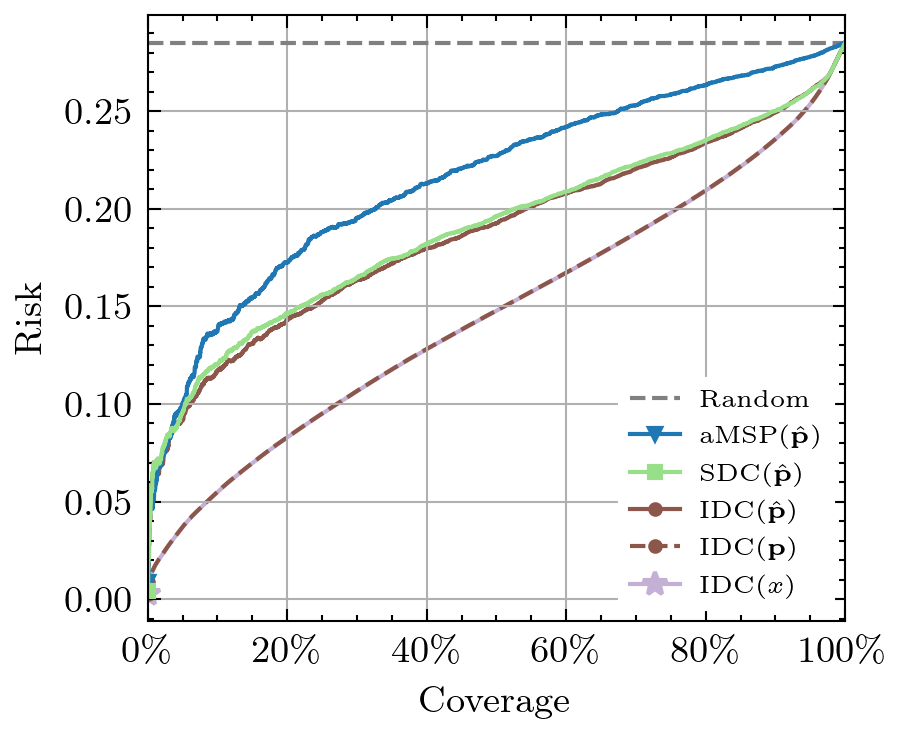

In [37]:
with open(f"perturbed_model_n_10_results.pkl", "rb") as f:
    results = pickle.load(f)

with open(f"perturbed_model_n_10_rc_curve_small.pkl", "rb") as f:
    curves = pickle.load(f)

fig, ax = plt.subplots()

markevery = 5000

idc_coverages, idc_risks = curves["IDC_FP"]
ax.hlines(idc_risks[-1], 0, 1, **styles["random"], label="Random")

coverages, risks = curves["aMSP"]
ax.plot(coverages, risks, **styles["amsp"], markevery=markevery, label=r"aMSP($\hat{\textbf{p}}$)")

coverages, sdc_risks = curves["SDC"]
ax.plot(coverages, sdc_risks, **styles["sdc"], markevery=markevery, label=r"SDC($\hat{\textbf{p}}$)")

hidc_coverages, hidc_risks = curves["IDC_hat"]
ax.plot(hidc_coverages, hidc_risks, **styles["idc_hat"], markevery=markevery, label=r"IDC($\hat{\textbf{p}}$)")

idc_mar_coverages, idc_mar_risks = curves["IDC_MAR"]
ax.plot(idc_mar_coverages, idc_mar_risks, **styles["idc_hat"], linestyle='--', markevery=markevery, label=r"IDC($\textbf{p}$)")

ax.plot(idc_coverages, idc_risks, **styles["idc_true"], markevery=markevery, label=r"IDC($x$)")

ax.legend()
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Coverage")
ax.set_ylabel("Risk")

fig.show()
fig.savefig("perturbed_model_rc_short.pdf")

## Varying Perturbation

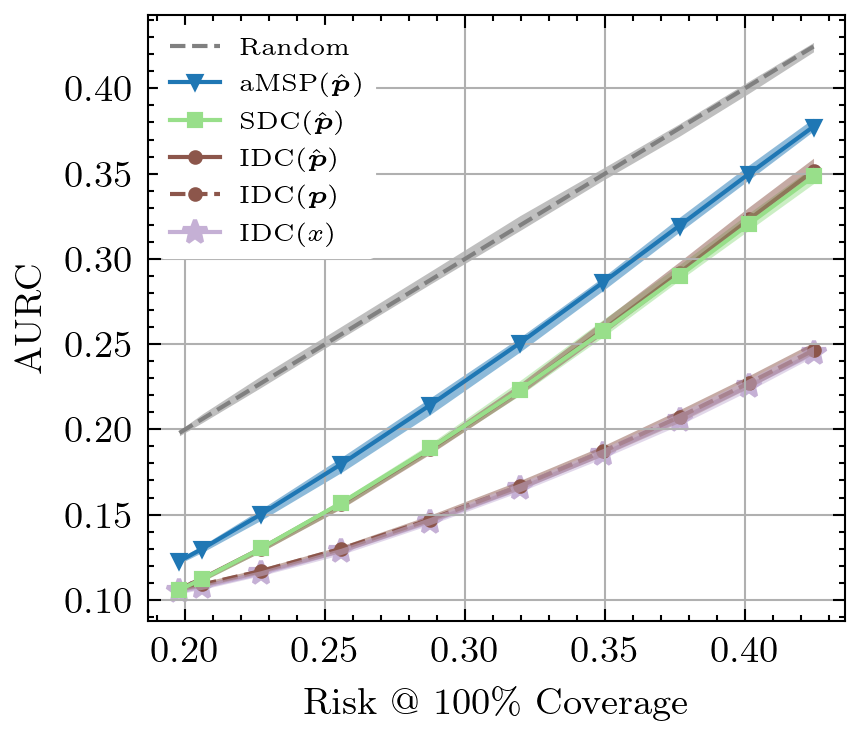

In [37]:
with open(f"perturbed_model_n_10_varying_perturbation.pkl", "rb") as f:
    data = pickle.load(f)

with open(f"perturbed_model_n_10_varying_perturbation_results.pkl", "rb") as f:
    raw_results = pickle.load(f)

base_risks = data["risks"]

r = 10
N = len(raw_results[0]["R_x"])
N_sample = int(N / r)

def get_aucs(raw_results, key):
    aucss = list()
    for raw_result in raw_results:
        aucs = list()
        for i in range(r):
            samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
            R_x = raw_result["R_x"][samples_slicer]
            conf = raw_result[key][samples_slicer]

            risks, coverages = rc_curve_(R_x, conf)
            aucs.append(auc(coverages, risks))
        aucss.append(np.array(aucs))

    return np.array(aucss)

sdc_aucs = get_aucs(raw_results, "SDC")
msp_aucs = get_aucs(raw_results, "aMSP")
idc_fp_aucs = get_aucs(raw_results, "IDC_FP")
idc_mar_aucs = get_aucs(raw_results, "IDC_MAR")
idc_hat_aucs = get_aucs(raw_results, "IDC_hat")

random_aucs = np.zeros_like(idc_fp_aucs)
for j, raw_result in enumerate(raw_results):
    for i in range(r):
        samples_slicer = slice(i * N_sample,(i + 1) * N_sample)
        R_x = raw_result["R_x"][samples_slicer]

        risks, _ = rc_curve_(R_x, -R_x)
        random_aucs[j, i] = risks[-1]

def add_rc_fill(ax, aucs, style_tag, label=None, **kwargs):
    aucs_min = np.min(aucs, axis=1)
    aucs_mean = np.mean(aucs, axis=1)
    aucs_max = np.max(aucs, axis=1)
    ax.fill_between(base_risks, aucs_min, aucs_max, alpha=0.5, linewidth=0, color=styles[style_tag]["color"])
    ax.plot(base_risks, aucs_mean, **styles[style_tag], label=label, **kwargs)

fig, ax = plt.subplots()

add_rc_fill(ax, random_aucs, "random", label=r"Random")
add_rc_fill(ax, msp_aucs, "amsp", label=r"aMSP($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, sdc_aucs, "sdc", label=r"SDC($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, idc_hat_aucs, "idc_hat", label=r"IDC($\hat{\boldsymbol{p}}$)")
add_rc_fill(ax, idc_mar_aucs, "idc_hat", label=r"IDC($\boldsymbol{p}$)", linestyle='--')
add_rc_fill(ax, idc_fp_aucs, "idc_true", label=r"IDC($x$)")

# ax.set_xlim(0.1,0.5)
ax.set_xlabel("Risk @ 100\% Coverage")
ax.set_ylabel("AURC")
ax.legend()

fig.show()
fig.savefig("perturbed_model_varying_perturbation_nruns.pdf")

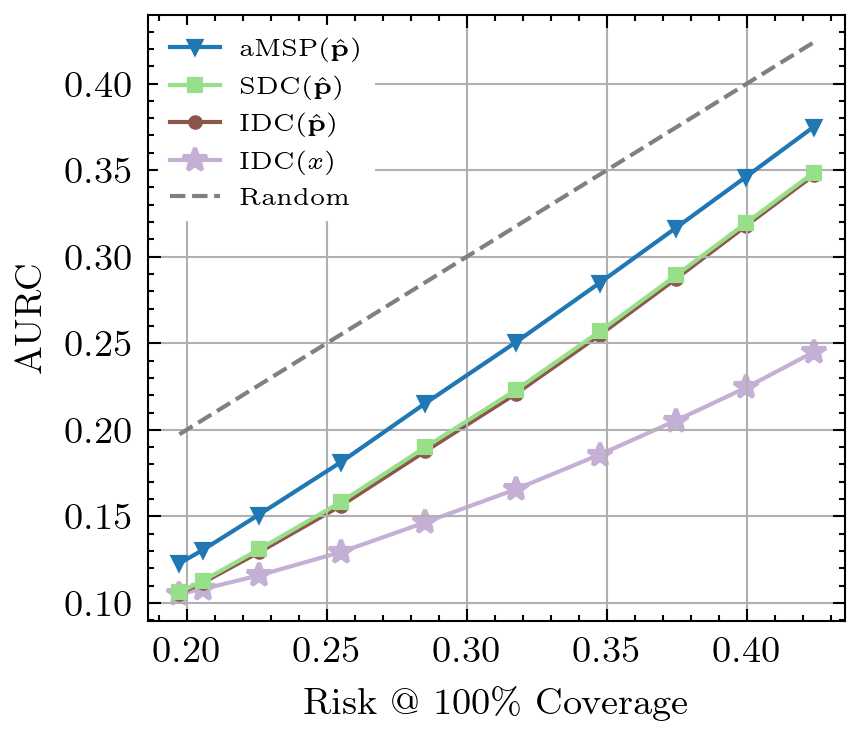

In [38]:
with open(f"perturbed_model_n_10_varying_perturbation.pkl", "rb") as f:
    data = pickle.load(f)

risks = data["risks"]
sdc_aucs = data["sdc_aucs"]
msp_aucs = data["msp_aucs"]
idc_aucs = data["idc_fp_aucs"]
hidc_aucs = data["idc_hat_aucs"]
random_aucs = data["random_aucs"]

fig, ax = plt.subplots()

ax.plot(risks, msp_aucs, **styles["amsp"], label=r"aMSP($\hat{\textbf{p}}$)")
ax.plot(risks, sdc_aucs, **styles["sdc"], label=r"SDC($\hat{\textbf{p}}$)")
ax.plot(risks, hidc_aucs, **styles["idc_hat"], label=r"IDC($\hat{\textbf{p}}$)")
ax.plot(risks, idc_aucs, **styles["idc_true"], label=r"IDC($x$)")
ax.plot(risks, random_aucs, **styles["random"], label="Random")

# ax.set_xlim(0.1,0.5)
ax.set_xlabel("Risk @ 100\% Coverage")
ax.set_ylabel("AURC")
ax.legend()

fig.show()
fig.savefig("perturbed_model_varying_perturbation.pdf")